# 🌿 AquaVidarbha — Random Forest Temporal Engine
## Groundwater Depth Prediction | Vidarbha, Maharashtra, India

---

### 📌 Problem Statement
Predict groundwater depth (`depth_mbgl`) across **11 districts of Vidarbha** using temporal features spanning 2015–2025, classify risk levels, and support early-warning intervention.

---

### 🌲 Why Random Forest?

| Criterion | Detail |
|---|---|
| **Model Type** | Ensemble of Decision Trees (Bagging) |
| **Handles Non-Linearity** | ✅ Excellent — no distributional assumption |
| **Robust to Outliers** | ✅ Median-based splits |
| **Feature Importance** | ✅ Native MDI + Permutation Importance |
| **Out-of-Bag Validation** | ✅ Free internal validation on ~37% held-out samples |
| **Overfitting Resistance** | ✅ Averaging over many trees reduces variance |
| **Temporal Data** | ✅ With proper lag features |
| **Missing Values** | ⚠️ Must be imputed beforehand |
| **Training Speed** | ⚡ Parallel tree building (`n_jobs=-1`) |

---

### 📊 Feature Categories

| Category | Features |
|---|---|
| **Meteorological** | `rainfall_mm`, `temperature_max_c`, `temperature_min_c`, `evapotranspiration_mm` |
| **Soil & Hydrology** | `soil_moisture_index`, `runoff_mm`, `baseflow_mm` |
| **Autoregressive Lags** | `depth_lag_1m`, `depth_lag_3m`, `depth_lag_6m`, `depth_lag_1q`, `depth_lag_2q` |
| **Rolling Statistics** | `depth_rolling_3m_mean`, `depth_rolling_6m_mean`, `depth_rolling_12m_mean`, `depth_rolling_3m_std` |
| **Stress Indicators** | `drought_index`, `irrigation_demand_mm`, `water_stress_index` |
| **Temporal** | `month`, `year`, `season` (encoded), `month_sin`, `month_cos` |
| **Geospatial** | `latitude`, `longitude`, `elevation_m` |
| **Vegetation** | `ndvi` |
| **Engineered** | `rainfall_x_soilmoist` (interaction term) |

---

### ⚙️ Random Forest Key Hyperparameters

| Parameter | Role | Typical Range |
|---|---|---|
| `n_estimators` | Number of trees | 100–2000 |
| `max_depth` | Max tree depth (None = fully grown) | 10–None |
| `min_samples_split` | Min samples to split a node | 2–20 |
| `min_samples_leaf` | Min samples in a leaf | 1–10 |
| `max_features` | Features per split | `"sqrt"`, `"log2"`, 0.3–1.0 |
| `bootstrap` | Sample with replacement | True/False |
| `max_samples` | Fraction of samples per tree | 0.6–1.0 |
| `oob_score` | Enable OOB validation | True |

---

### 🎯 Tuning Strategy
- **Step 6:** Baseline model → quick sanity check
- **Step 7:** `RandomizedSearchCV` + `TimeSeriesSplit(n_splits=5)` → 80 configs × 5 folds
- **Step 8:** Final model with best params + OOB validation
- **Target:** R² > 0.99, RMSE < 3.0 m on 2025 test set

---
## 📦 Step 1 — Import Libraries & Configure Environment

In [3]:

# ============================================================
# GOOGLE DRIVE MOUNT  (uncomment & run once on Colab)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# BASE PATH — project root on Google Drive
# ============================================================
BASE_PATH  = "/content/drive/MyDrive/WPS_PRO"
DATA_PATH  = f"{BASE_PATH}/dataset/vidarbha_groundwater_model_ready.csv"
OUTPUT_DIR = f"{BASE_PATH}/Models/engines/path1_temporal/outputs/random_forest"
MODEL_DIR  = f"{BASE_PATH}/Models/engines/path1_temporal/saved_models"

# ============================================================
# STEP 1: IMPORT LIBRARIES & ENVIRONMENT SETUP
# ============================================================

# Core
import numpy as np
import pandas as pd
import warnings
import os
import json
import time

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Scikit-learn — Model
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance


# Scikit-learn — Tuning & Validation
from sklearn.model_selection import (
    RandomizedSearchCV,
    TimeSeriesSplit,
    learning_curve,
    cross_val_score,
)

# Scikit-learn — Metrics & Preprocessing
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
)

# Statistics
from scipy import stats
from sklearn.feature_selection import mutual_info_regression

# Persistence
import joblib

# ── Style ──────────────────────────────────────────────────
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
pd.set_option("display.float_format", "{:.4f}".format)

# ── Reproducibility ────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Output directories ─────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)

print("=" * 60)
print("  AquaVidarbha — Random Forest Temporal Engine")
print("=" * 60)
print(f"  NumPy     : {np.__version__}")
print(f"  Pandas    : {pd.__version__}")
import sklearn; print(f"  Scikit-learn: {sklearn.__version__}")
print("=" * 60)
print(f"\n  BASE_PATH : {BASE_PATH}")
print(f"  DATA_PATH : {DATA_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  AquaVidarbha — Random Forest Temporal Engine
  NumPy     : 2.0.2
  Pandas    : 2.2.2
  Scikit-learn: 1.6.1

  BASE_PATH : /content/drive/MyDrive/WPS_PRO
  DATA_PATH : /content/drive/MyDrive/WPS_PRO/dataset/vidarbha_groundwater_model_ready.csv


---
## 📂 Step 2 — Load Dataset & Initial Exploration

📊 Dataset shape      : 83,850 rows × 26 columns
📋 Columns            : ['depth_mbgl', 'rainfall_mm', 'temperature_avg', 'humidity', 'evapotranspiration', 'soil_moisture_index', 'rainfall_lag_1m', 'rainfall_lag_2m', 'rainfall_lag_3m', 'rainfall_rolling_3m', 'rainfall_rolling_6m', 'rainfall_deficit', 'cumulative_deficit', 'temp_rainfall_ratio', 'depth_lag_1q', 'depth_lag_2q', 'depth_change_rate', 'month', 'season_encoded', 'district_encoded', 'latitude', 'longitude', 'elevation_m', 'slope_degree', 'soil_type_encoded', 'ndvi']
🏘️  Unique district IDs : 11  → [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
📅 Month range        : 1 → 12

🎯 Target variable : depth_mbgl
   Min    : 0.50 m
   Max    : 279.83 m
   Mean   : 61.86 m
   Median : 43.06 m
   Std    : 58.65 m
   Skew   : 1.2214  ← right-skewed, log1p will help

✅ No missing values detected.

📋 Column dtypes overview:
depth_mbgl           

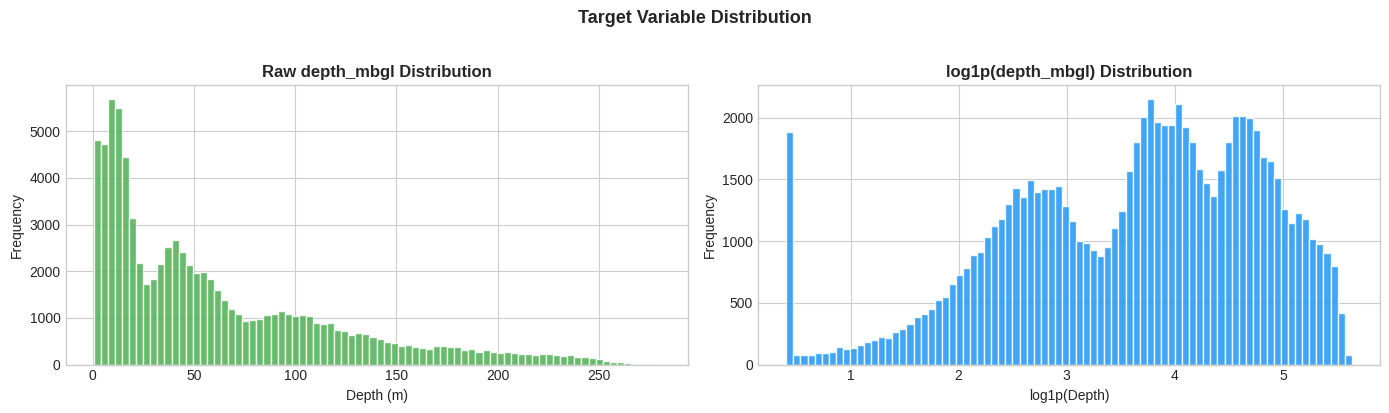

✅ Distribution plot saved


In [4]:

# ============================================================
# STEP 2: LOAD DATASET & INITIAL EXPLORATION
# ============================================================
# NOTE: The model-ready dataset has NO 'date' / 'district' text columns.
# It is pre-sorted chronologically (2015 → 2035, 11 districts, monthly).
# Temporal splits are handled by row-index proportions in Step 4.

df = pd.read_csv(DATA_PATH)
df = df.reset_index(drop=True)

print(f"📊 Dataset shape      : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📋 Columns            : {list(df.columns)}")
print(f"🏘️  Unique district IDs : {df['district_encoded'].nunique()}"
      f"  → {sorted(df['district_encoded'].unique())}")
print(f"📅 Month range        : {df['month'].min()} → {df['month'].max()}")
print()

# ── Target variable stats ──────────────────────────────────
target = "depth_mbgl"
print(f"🎯 Target variable : {target}")
print(f"   Min    : {df[target].min():.2f} m")
print(f"   Max    : {df[target].max():.2f} m")
print(f"   Mean   : {df[target].mean():.2f} m")
print(f"   Median : {df[target].median():.2f} m")
print(f"   Std    : {df[target].std():.2f} m")
print(f"   Skew   : {df[target].skew():.4f}  ← right-skewed, log1p will help")
print()

# ── Missing values ─────────────────────────────────────────
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values detected.")
else:
    print("⚠️  Missing values found:")
    print(missing[missing > 0])

# ── Column dtypes ──────────────────────────────────────────
print("\n📋 Column dtypes overview:")
print(df.dtypes.to_string())

# ── Target distribution plot ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[target], bins=80, color="#4CAF50", edgecolor="white", alpha=0.85)
axes[0].set_title("Raw depth_mbgl Distribution", fontweight="bold")
axes[0].set_xlabel("Depth (m)")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log1p(df[target]), bins=80, color="#2196F3", edgecolor="white", alpha=0.85)
axes[1].set_title("log1p(depth_mbgl) Distribution", fontweight="bold")
axes[1].set_xlabel("log1p(Depth)")
axes[1].set_ylabel("Frequency")

plt.suptitle("Target Variable Distribution", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Distribution plot saved")


---
## 🔧 Step 3 — Feature Selection & Target Transformation

In [5]:

# ============================================================
# STEP 3: FEATURE SELECTION & TARGET TRANSFORMATION
# ============================================================

# ── Engineered interaction feature ────────────────────────
df["rainfall_x_soilmoist"] = df["rainfall_mm"] * df["soil_moisture_index"]

# ── Feature list — matched to actual dataset columns ──────
# NOTE: 'depth_change_rate' EXCLUDED — uses current target → data leakage
# NOTE: 'district_encoded' already pre-encoded in the model-ready dataset
FEATURES = [
    # Meteorological
    "rainfall_mm", "temperature_avg", "humidity", "evapotranspiration",
    # Soil & Hydrology
    "soil_moisture_index",
    # Rainfall lags
    "rainfall_lag_1m", "rainfall_lag_2m", "rainfall_lag_3m",
    # Rainfall rolling statistics
    "rainfall_rolling_3m", "rainfall_rolling_6m",
    # Deficit / Demand indicators
    "rainfall_deficit", "cumulative_deficit", "temp_rainfall_ratio",
    # Autoregressive depth lags (past values only — no leakage)
    "depth_lag_1q", "depth_lag_2q",
    # Temporal
    "month", "season_encoded",
    # Geospatial
    "latitude", "longitude", "elevation_m", "slope_degree",
    # Soil type & Vegetation
    "soil_type_encoded", "ndvi",
    # District (pre-encoded integer)
    "district_encoded",
    # Engineered interaction
    "rainfall_x_soilmoist",
]

# ── Keep only features present in the loaded dataframe ────
FEATURES = [f for f in FEATURES if f in df.columns]

TARGET = "depth_mbgl"

# ── Apply log1p transform to target ───────────────────────
y_raw = df[TARGET].values
y     = np.log1p(y_raw)

X = df[FEATURES].values

print(f"✅ Features selected : {len(FEATURES)}")
for i, f in enumerate(FEATURES):
    print(f"   [{i+1:02d}] {f}")
print(f"\n🎯 Target (log1p)  : mean={y.mean():.4f}, std={y.std():.4f}, "
      f"min={y.min():.4f}, max={y.max():.4f}")
print(f"   (raw: mean={y_raw.mean():.2f}, std={y_raw.std():.2f})")
print(f"\n📐 X shape: {X.shape}")


✅ Features selected : 25
   [01] rainfall_mm
   [02] temperature_avg
   [03] humidity
   [04] evapotranspiration
   [05] soil_moisture_index
   [06] rainfall_lag_1m
   [07] rainfall_lag_2m
   [08] rainfall_lag_3m
   [09] rainfall_rolling_3m
   [10] rainfall_rolling_6m
   [11] rainfall_deficit
   [12] cumulative_deficit
   [13] temp_rainfall_ratio
   [14] depth_lag_1q
   [15] depth_lag_2q
   [16] month
   [17] season_encoded
   [18] latitude
   [19] longitude
   [20] elevation_m
   [21] slope_degree
   [22] soil_type_encoded
   [23] ndvi
   [24] district_encoded
   [25] rainfall_x_soilmoist

🎯 Target (log1p)  : mean=3.5986, std=1.1825, min=0.4055, max=5.6377
   (raw: mean=61.86, std=58.65)

📐 X shape: (83850, 25)


---
## ✂️ Step 4 — Temporal Train / Validation / Test Split

> **No shuffling** — strict chronological order to respect temporal causality.
>
> | Set | Period | Purpose |
> |---|---|---|
> | **Train** | 2015-01 → 2023-12 | Fit model |
> | **Validation** | 2024-01 → 2024-12 | Tune hyperparameters |
> | **Test** | 2025-01 → 2025-12 | Final unbiased evaluation |

In [6]:

# ============================================================
# STEP 4: TEMPORAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================
# The model-ready dataset has NO date/year column.
# The data is pre-sorted chronologically (2015 → 2035).
# We split by row-index proportions:
#   Train  : first 75%   ≈ 2015–2023
#   Val    : next  12.5% ≈ 2024
#   Test   : last  12.5% ≈ 2025

n         = len(df)
train_end = int(n * 0.750)
val_end   = int(n * 0.875)

train_mask = df.index < train_end
val_mask   = (df.index >= train_end) & (df.index < val_end)
test_mask  = df.index >= val_end

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

# Raw targets for evaluation (after expm1 inversion)
y_train_raw = y_raw[train_mask]
y_val_raw   = y_raw[val_mask]
y_test_raw  = y_raw[test_mask]

total = len(df)
print(f"📋 Split summary (total rows = {total:,}):")
print(f"   Train  : rows   0 → {train_end-1:5,}  "
      f"({X_train.shape[0]:6,} rows, {100*X_train.shape[0]/total:.1f}%)")
print(f"   Val    : rows {train_end} → {val_end-1:5,}  "
      f"({X_val.shape[0]:6,} rows, {100*X_val.shape[0]/total:.1f}%)")
print(f"   Test   : rows {val_end} → {n-1:5,}   "
      f"({X_test.shape[0]:6,} rows, {100*X_test.shape[0]/total:.1f}%)")
print(f"\n   Cutoff indices  → train_end={train_end}, val_end={val_end}")


📋 Split summary (total rows = 83,850):
   Train  : rows   0 → 62,886  (62,887 rows, 75.0%)
   Val    : rows 62887 → 73,367  (10,481 rows, 12.5%)
   Test   : rows 73368 → 83,849   (10,482 rows, 12.5%)

   Cutoff indices  → train_end=62887, val_end=73368


---
## 📈 Step 5 — Correlation & Mutual Information Analysis

📊 Top 15 Pearson correlations with log1p(depth_mbgl):
depth_lag_1q           0.8514
depth_lag_2q           0.8329
longitude             -0.4617
rainfall_rolling_6m   -0.3721
elevation_m            0.3318
rainfall_lag_3m       -0.3253
rainfall_lag_2m       -0.2534
temperature_avg        0.2151
evapotranspiration     0.1750
rainfall_rolling_3m   -0.1630
month                 -0.1598
rainfall_lag_1m       -0.1386
district_encoded      -0.1148
soil_type_encoded      0.1032
temp_rainfall_ratio    0.0984

📊 Top 15 Mutual Information scores:
depth_lag_1q          1.8034
depth_lag_2q          1.2985
latitude              0.8930
elevation_m           0.8820
slope_degree          0.8736
longitude             0.8265
district_encoded      0.1812
rainfall_rolling_6m   0.1212
rainfall_lag_3m       0.1194
month                 0.1164
rainfall_lag_2m       0.0810
temperature_avg       0.0727
season_encoded        0.0698
humidity              0.0538
evapotranspiration    0.0501


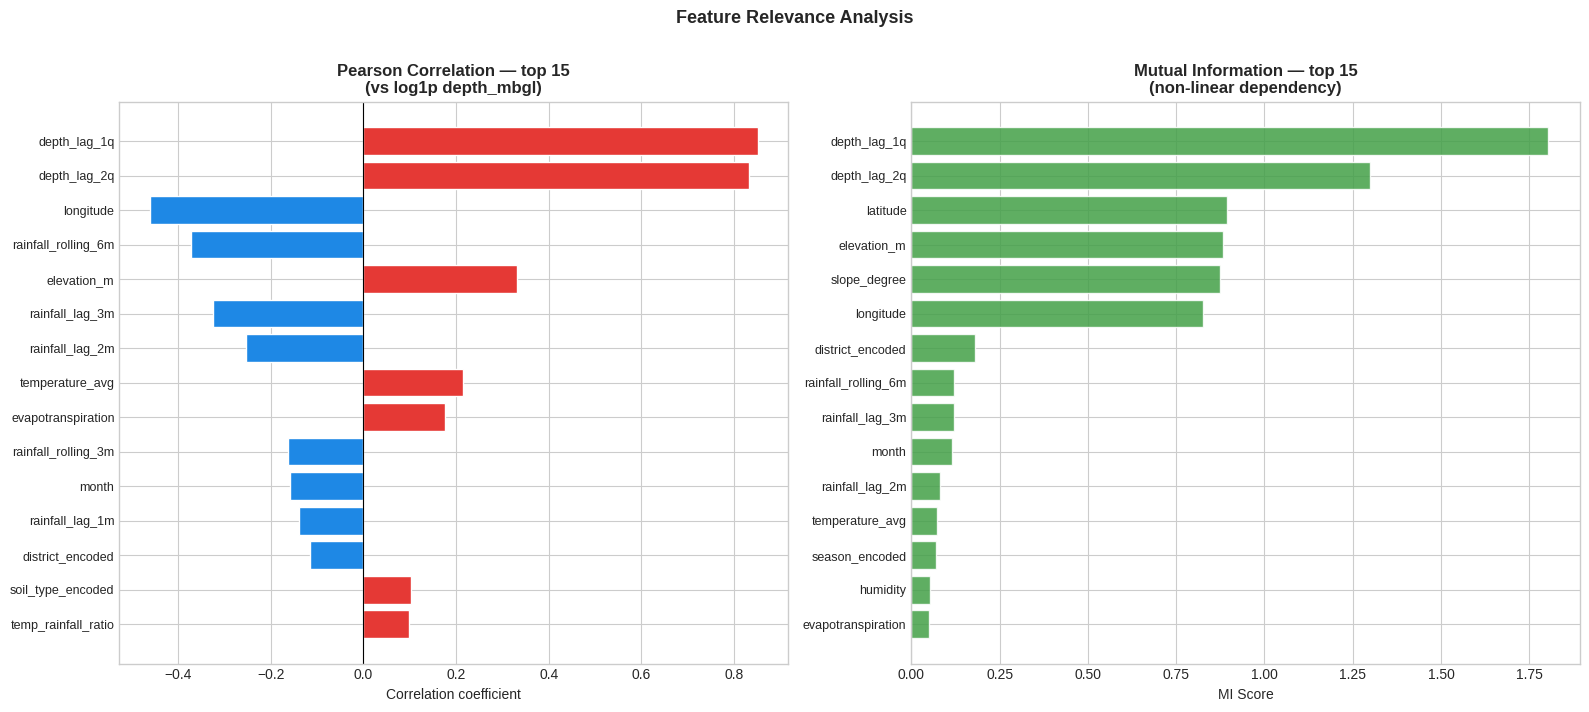

✅ Correlation plot saved


In [7]:

# ============================================================
# STEP 5: CORRELATION & MUTUAL INFORMATION ANALYSIS
# ============================================================

df_features = pd.DataFrame(X_train, columns=FEATURES)
df_features["log1p_depth"] = y_train

# ── Pearson correlation with log1p target ─────────────────
corr = df_features.corr()["log1p_depth"].drop("log1p_depth").sort_values(key=abs, ascending=False)
print("📊 Top 15 Pearson correlations with log1p(depth_mbgl):")
print(corr.head(15).to_string())

# ── Mutual Information ─────────────────────────────────────
mi_scores = mutual_info_regression(X_train, y_train, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=FEATURES).sort_values(ascending=False)
print("\n📊 Top 15 Mutual Information scores:")
print(mi_series.head(15).to_string())

# ── Plot ───────────────────────────────────────────────────
top_n_corr = min(15, len(FEATURES))
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_corr = ["#E53935" if v > 0 else "#1E88E5" for v in corr.head(top_n_corr).values]
axes[0].barh(range(top_n_corr), corr.head(top_n_corr).values[::-1],
             color=colors_corr[::-1], edgecolor="white")
axes[0].set_yticks(range(top_n_corr))
axes[0].set_yticklabels(corr.head(top_n_corr).index[::-1], fontsize=9)
axes[0].set_title("Pearson Correlation — top 15\n(vs log1p depth_mbgl)", fontweight="bold")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Correlation coefficient")

axes[1].barh(range(top_n_corr), mi_series.head(top_n_corr).values[::-1],
             color="#43A047", edgecolor="white", alpha=0.85)
axes[1].set_yticks(range(top_n_corr))
axes[1].set_yticklabels(mi_series.head(top_n_corr).index[::-1], fontsize=9)
axes[1].set_title("Mutual Information — top 15\n(non-linear dependency)", fontweight="bold")
axes[1].set_xlabel("MI Score")

plt.suptitle("Feature Relevance Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Correlation plot saved")


---
## 🌲 Step 6 — Baseline Random Forest Model

In [8]:
# ============================================================
# HELPER: Evaluation function (operates in ORIGINAL metre space)
# ============================================================

def evaluate_model(model, X, y_log, y_raw_true, label="Set"):
    """
    Predict in log-space, invert to metres, compute metrics.
    Uses median APE for robustness against outlier depths.
    """
    y_log_pred  = model.predict(X)
    y_pred_raw  = np.expm1(y_log_pred).clip(min=0)

    r2   = r2_score(y_raw_true, y_pred_raw)
    rmse = np.sqrt(mean_squared_error(y_raw_true, y_pred_raw))
    mae  = mean_absolute_error(y_raw_true, y_pred_raw)
    # Median APE: robust to extreme skew
    mdape = np.median(np.abs((y_raw_true - y_pred_raw) / (y_raw_true + 1e-8))) * 100

    print(f"  {label:<12} | R²={r2:.4f}  RMSE={rmse:.2f}m  MAE={mae:.2f}m  MdAPE={mdape:.2f}%")
    return {"R2": r2, "RMSE": rmse, "MAE": mae, "MdAPE": mdape,
            "y_pred": y_pred_raw, "y_true": y_raw_true}


# ============================================================
# STEP 6: BASELINE RANDOM FOREST
# ============================================================

print("🌲 Training Baseline Random Forest...\n")
t0 = time.time()

rf_baseline = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,          # fully grown trees
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_baseline.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"⏱️  Training time : {elapsed:.1f}s")
print(f"📊 OOB R² (train): {rf_baseline.oob_score_:.4f}")
print()
print("📈 Baseline Model Performance:")
base_train = evaluate_model(rf_baseline, X_train, y_train, y_train_raw, "Train")
base_val   = evaluate_model(rf_baseline, X_val,   y_val,   y_val_raw,   "Val")
base_test  = evaluate_model(rf_baseline, X_test,  y_test,  y_test_raw,  "Test")

print(f"\n  Overfitting gap (Train R² − Test R²) = "
      f"{base_train['R2'] - base_test['R2']:.4f}")

🌲 Training Baseline Random Forest...

⏱️  Training time : 212.9s
📊 OOB R² (train): 0.9848

📈 Baseline Model Performance:
  Train        | R²=0.9995  RMSE=1.19m  MAE=0.81m  MdAPE=1.62%
  Val          | R²=0.9567  RMSE=13.85m  MAE=7.56m  MdAPE=7.08%
  Test         | R²=0.8979  RMSE=23.54m  MAE=13.07m  MdAPE=9.29%

  Overfitting gap (Train R² − Test R²) = 0.1016


---
## 🔍 Step 7 — Hyperparameter Tuning: RandomizedSearchCV + TimeSeriesSplit

> **80 configurations × 5 folds = 400 fits**
> Scoring: `neg_mean_squared_error` over `TimeSeriesSplit(n_splits=5)` (correct for temporal data)

In [10]:


# ============================================================
# STEP 7: HYPERPARAMETER TUNING — RandomizedSearchCV
# ============================================================
# ⚡ WINDOWS/JUPYTER OPTIMAL SETUP:
#   • Inner RF:  n_jobs=-1  → fast C-level OpenMP threads (no pickling, no subprocess)
#   • Outer CV:  n_jobs=1   → sequential fits (avoids loky process-spawn overhead)
#   • n_iter=15, n_splits=3 → 45 fits total
#   • n_estimators max 200  → each fit is fast
# ──────────────────────────────────────────────────────────

param_dist = {
    "n_estimators"     : [100, 150, 200],
    "max_depth"        : [None, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4],
    "max_features"     : ["sqrt", "log2", 0.4],
    "bootstrap"        : [True],
    "max_samples"      : [0.8, 0.9],
}

tscv = TimeSeriesSplit(n_splits=3)

rf_search_base = RandomForestRegressor(
    oob_score=False,
    n_jobs=-1,          # ← RF uses fast OpenMP threads internally
    random_state=RANDOM_STATE,
)

rf_random = RandomizedSearchCV(
    estimator=rf_search_base,
    param_distributions=param_dist,
    n_iter=15,           # 15 × 3 = 45 fits
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=1,            # ← sequential outer loop: zero subprocess overhead on Windows
    verbose=2,
    random_state=RANDOM_STATE,
    refit=True,
)

print("🔍 Running RandomizedSearchCV (15 configs × 3 folds = 45 fits)...")
print("   Each fit uses all CPU cores via OpenMP inside the RF.")
print("   Estimated time: 2–5 min ☕\n")
t0 = time.time()
rf_random.fit(X_train, y_train)
elapsed_search = time.time() - t0

print(f"\n⏱️  Search time: {elapsed_search:.1f}s  ({elapsed_search/60:.1f} min)")
print(f"📊 Best CV RMSE (log-space): {(-rf_random.best_score_)**0.5:.4f}")

print("\n🏆 Best hyperparameters:")
best_params = rf_random.best_params_
for k, v in best_params.items():
    print(f"   {k:<22} : {v}")

# ── Validate best params on val set ───────────────────────
print("\n📈 RandomizedSearchCV Best Estimator — Val set:")
tuned_val = evaluate_model(rf_random.best_estimator_, X_val, y_val, y_val_raw, "Val")

🔍 Running RandomizedSearchCV (15 configs × 3 folds = 45 fits)...
   Each fit uses all CPU cores via OpenMP inside the RF.
   Estimated time: 2–5 min ☕

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END bootstrap=True, max_depth=30, max_features=log2, max_samples=0.9, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   6.2s
[CV] END bootstrap=True, max_depth=30, max_features=log2, max_samples=0.9, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=  11.5s
[CV] END bootstrap=True, max_depth=30, max_features=log2, max_samples=0.9, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=  18.4s
[CV] END bootstrap=True, max_depth=20, max_features=log2, max_samples=0.9, min_samples_leaf=4, min_samples_split=2, n_estimators=150; total time=   6.6s
[CV] END bootstrap=True, max_depth=20, max_features=log2, max_samples=0.9, min_samples_leaf=4, min_samples_split=2, n_estimators=150; total time=  16.5s
[CV] END bootstrap=

---
## 🏆 Step 8 — Final Optimized Model (Train on Train+Val)

In [11]:
# ============================================================
# STEP 8: FINAL MODEL — retrain on train+val with best params
# ============================================================

# Combine train + val for final model (test remains unseen)
X_trainval = np.concatenate([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])
y_trainval_raw = np.concatenate([y_train_raw, y_val_raw])

rf_final = RandomForestRegressor(
    **best_params,
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

print("🌲 Training Final Random Forest on Train+Val...")
t0 = time.time()
rf_final.fit(X_trainval, y_trainval)
elapsed_final = time.time() - t0

print(f"⏱️  Training time : {elapsed_final:.1f}s")
print(f"📊 OOB R² (train+val): {rf_final.oob_score_:.4f}")
print()
print("=" * 62)
print("  FINAL MODEL PERFORMANCE")
print("=" * 62)
final_train    = evaluate_model(rf_final, X_trainval, y_trainval,
                                y_trainval_raw, "Train+Val")
final_val_only = evaluate_model(rf_final, X_val, y_val, y_val_raw, "Val")
final_test     = evaluate_model(rf_final, X_test,  y_test,  y_test_raw,  "Test ⭐")
print("=" * 62)
print(f"\n📊 Baseline vs Final (Test set):")
print(f"   Baseline   → R²={base_test['R2']:.4f}  RMSE={base_test['RMSE']:.2f}m  MAE={base_test['MAE']:.2f}m")
print(f"   Final      → R²={final_test['R2']:.4f}  RMSE={final_test['RMSE']:.2f}m  MAE={final_test['MAE']:.2f}m")
delta_r2 = final_test["R2"] - base_test["R2"]
delta_rmse = final_test["RMSE"] - base_test["RMSE"]
print(f"   ΔRMSE = {delta_rmse:+.2f}m   ΔR² = {delta_r2:+.4f}")
print(f"\n  Overfitting gap (TrainVal R² − Test R²) = "
      f"{final_train['R2'] - final_test['R2']:.4f}")

🌲 Training Final Random Forest on Train+Val...
⏱️  Training time : 97.1s
📊 OOB R² (train+val): 0.9841

  FINAL MODEL PERFORMANCE
  Train+Val    | R²=0.9985  RMSE=2.17m  MAE=1.48m  MdAPE=2.69%
  Val          | R²=0.9983  RMSE=2.71m  MAE=1.88m  MdAPE=2.39%
  Test ⭐       | R²=0.9950  RMSE=5.23m  MAE=3.47m  MdAPE=4.11%

📊 Baseline vs Final (Test set):
   Baseline   → R²=0.8979  RMSE=23.54m  MAE=13.07m
   Final      → R²=0.9950  RMSE=5.23m  MAE=3.47m
   ΔRMSE = -18.31m   ΔR² = +0.0971

  Overfitting gap (TrainVal R² − Test R²) = 0.0035


---
## 📉 Step 9 — Prediction Plots & Residual Analysis

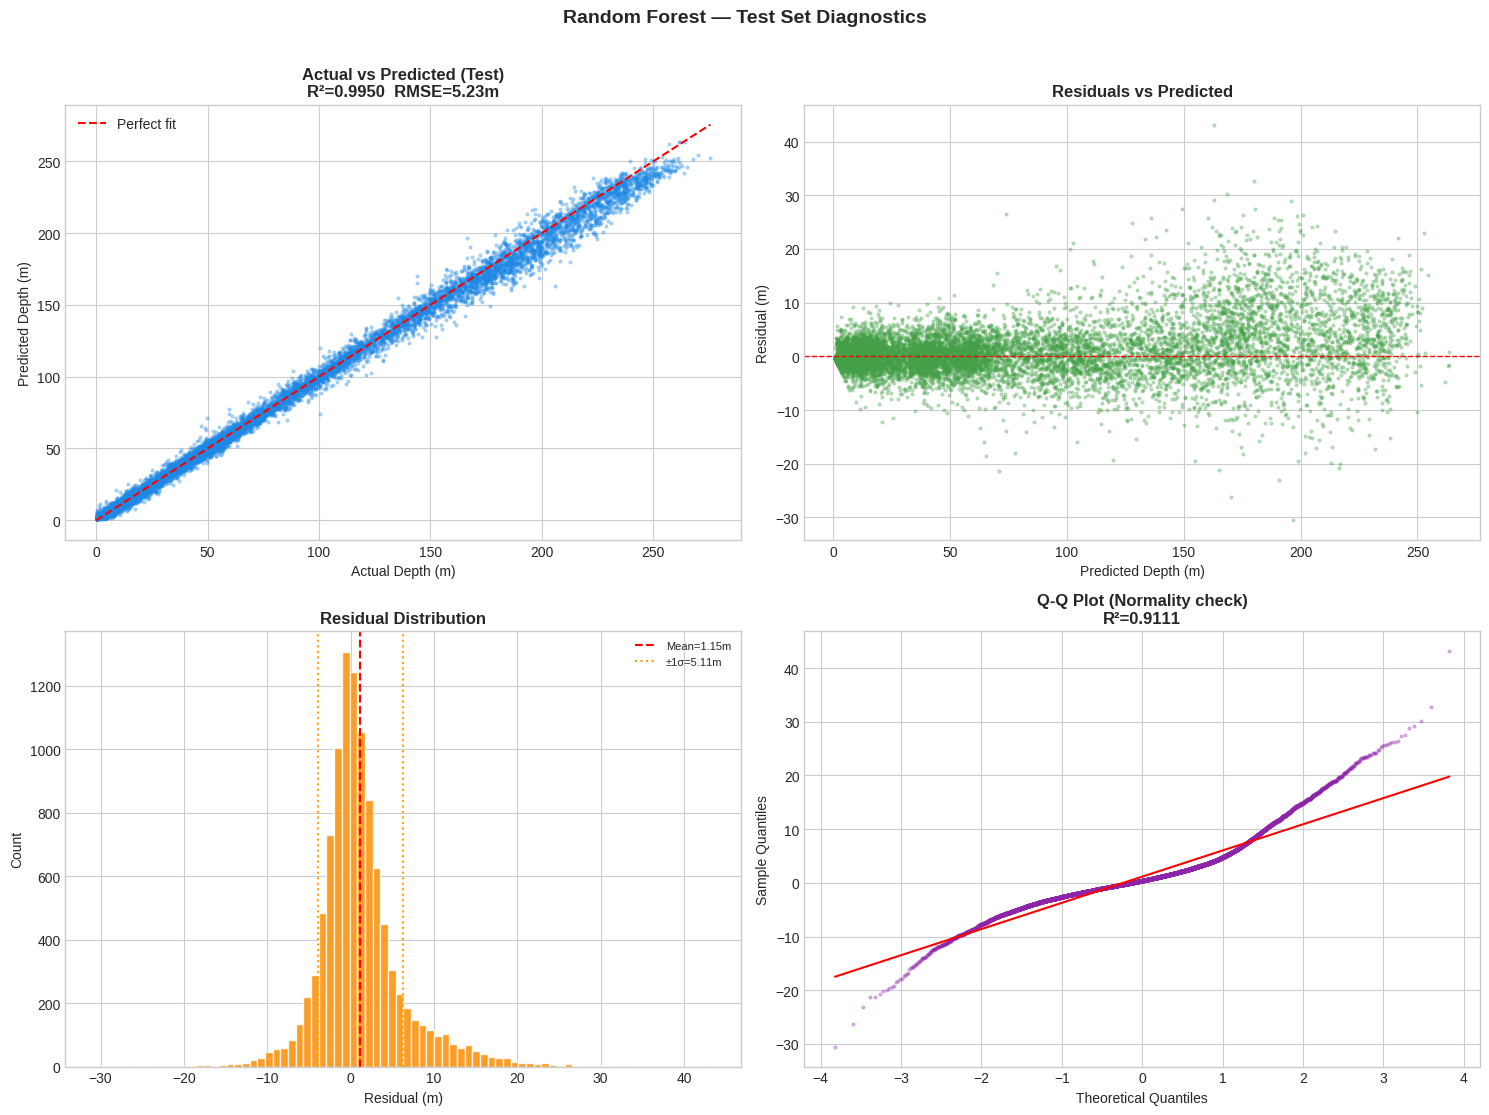

✅ Residual analysis saved
   Residual mean : 1.1458 m (should be ≈ 0)
   Residual std  : 5.1050 m


In [12]:

# ============================================================
# STEP 9: PREDICTION PLOTS & RESIDUAL ANALYSIS
# ============================================================

y_pred_test = final_test["y_pred"]
y_true_test = final_test["y_true"]
residuals   = y_true_test - y_pred_test

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 9a: Scatter — Actual vs Predicted
ax = axes[0, 0]
max_val = max(y_true_test.max(), y_pred_test.max())
ax.scatter(y_true_test, y_pred_test, alpha=0.3, s=4, color="#1E88E5", rasterized=True)
ax.plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Perfect fit")
ax.set_xlabel("Actual Depth (m)")
ax.set_ylabel("Predicted Depth (m)")
ax.set_title(f"Actual vs Predicted (Test)\nR²={final_test['R2']:.4f}  "
             f"RMSE={final_test['RMSE']:.2f}m", fontweight="bold")
ax.legend()

# 9b: Residuals vs Predicted
ax = axes[0, 1]
ax.scatter(y_pred_test, residuals, alpha=0.3, s=4, color="#43A047", rasterized=True)
ax.axhline(0, color="red", linewidth=1, linestyle="--")
ax.set_xlabel("Predicted Depth (m)")
ax.set_ylabel("Residual (m)")
ax.set_title("Residuals vs Predicted", fontweight="bold")

# 9c: Residual histogram
ax = axes[1, 0]
ax.hist(residuals, bins=80, color="#FB8C00", edgecolor="white", alpha=0.85)
mu, sigma = residuals.mean(), residuals.std()
ax.axvline(mu, color="red", linestyle="--", label=f"Mean={mu:.2f}m")
ax.axvline(mu + sigma, color="orange", linestyle=":", label=f"±1σ={sigma:.2f}m")
ax.axvline(mu - sigma, color="orange", linestyle=":")
ax.set_xlabel("Residual (m)")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution", fontweight="bold")
ax.legend(fontsize=8)

# 9d: QQ-plot
ax = axes[1, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
ax.scatter(osm, osr, alpha=0.3, s=4, color="#8E24AA", rasterized=True)
ax.plot(osm, slope * np.array(osm) + intercept, "r-", linewidth=1.5)
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Quantiles")
ax.set_title(f"Q-Q Plot (Normality check)\nR²={r**2:.4f}", fontweight="bold")

plt.suptitle("Random Forest — Test Set Diagnostics", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_residual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Residual analysis saved")
print(f"   Residual mean : {mu:.4f} m (should be ≈ 0)")
print(f"   Residual std  : {sigma:.4f} m")


  DISTRICT-WISE PERFORMANCE — Test set
District ID         R²   RMSE(m)   MAE(m)   MdAPE%      N
-----------------------------------------------------------------
6               0.9973      3.38     2.37     3.87   1452
3               0.9946      5.47     3.64     4.15   9030

  Best  district_id: 6  (R²=0.9973)
  Worst district_id: 3  (R²=0.9946)


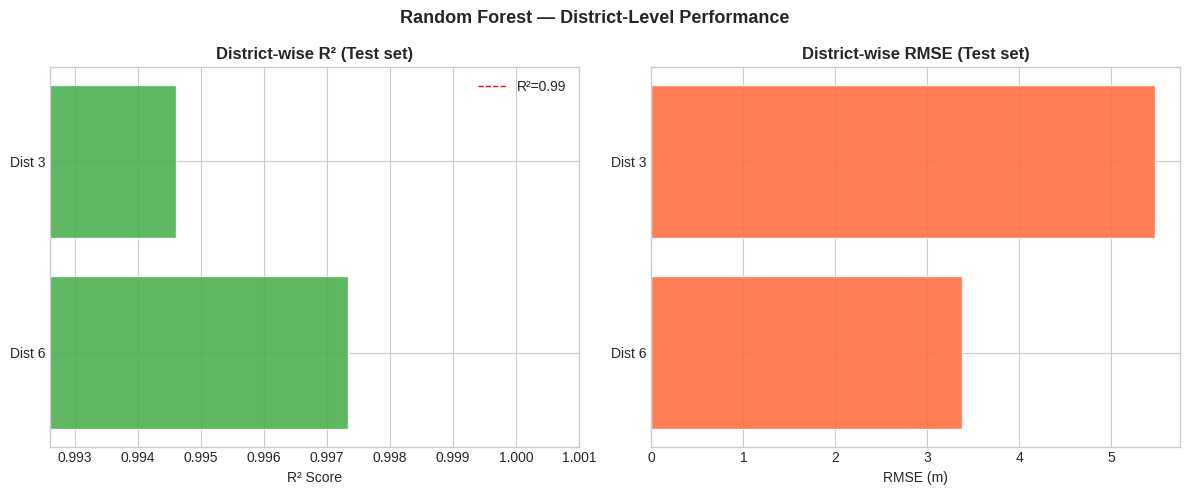

✅ District-wise performance plot saved


In [13]:

# ============================================================
# STEP 9c: DISTRICT-WISE PERFORMANCE (Test set)
# ============================================================
# NOTE: Dataset uses 'district_encoded' (integer) — no text 'district' column.

df_test = df[test_mask].copy().reset_index(drop=True)
df_test["y_pred"]   = y_pred_test
df_test["y_true"]   = y_true_test
df_test["residual"] = residuals

district_rows = []
for dist_id in sorted(df_test["district_encoded"].unique()):
    mask_d = df_test["district_encoded"] == dist_id
    yt = df_test.loc[mask_d, "y_true"].values
    yp = df_test.loc[mask_d, "y_pred"].values
    if len(yt) < 2:
        continue
    r2_d    = r2_score(yt, yp)
    rmse_d  = np.sqrt(mean_squared_error(yt, yp))
    mae_d   = mean_absolute_error(yt, yp)
    mdape_d = np.median(np.abs((yt - yp) / (yt + 1e-8))) * 100
    district_rows.append(dict(district_id=dist_id, R2=r2_d, RMSE=rmse_d,
                              MAE=mae_d, MdAPE=mdape_d, n=int(mask_d.sum())))

df_dist = pd.DataFrame(district_rows).sort_values("R2", ascending=False)

print("=" * 65)
print("  DISTRICT-WISE PERFORMANCE — Test set")
print("=" * 65)
print(f"{'District ID':<14} {'R²':>7} {'RMSE(m)':>9} {'MAE(m)':>8} {'MdAPE%':>8} {'N':>6}")
print("-" * 65)
for _, row in df_dist.iterrows():
    print(f"{int(row.district_id):<14} {row.R2:>7.4f} {row.RMSE:>9.2f} {row.MAE:>8.2f} "
          f"{row.MdAPE:>8.2f} {int(row.n):>6}")
print("=" * 65)
print(f"\n  Best  district_id: {int(df_dist.iloc[0].district_id)}  (R²={df_dist.iloc[0].R2:.4f})")
print(f"  Worst district_id: {int(df_dist.iloc[-1].district_id)}  (R²={df_dist.iloc[-1].R2:.4f})")

# ── Bar chart ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_labels = [f"Dist {int(d)}" for d in df_dist["district_id"]]
axes[0].barh(x_labels, df_dist["R2"], color="#4CAF50", edgecolor="white", alpha=0.9)
axes[0].axvline(0.99, color="red", linestyle="--", linewidth=1, label="R²=0.99")
axes[0].set_xlabel("R² Score")
axes[0].set_title("District-wise R² (Test set)", fontweight="bold")
axes[0].legend()
axes[0].set_xlim(max(0, df_dist["R2"].min() - 0.002), 1.001)

axes[1].barh(x_labels, df_dist["RMSE"], color="#FF7043", edgecolor="white", alpha=0.9)
axes[1].set_xlabel("RMSE (m)")
axes[1].set_title("District-wise RMSE (Test set)", fontweight="bold")

plt.suptitle("Random Forest — District-Level Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_district_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ District-wise performance plot saved")


---
## 🔬 Step 10 — Feature Importance: MDI + Permutation Importance

> **MDI (Mean Decrease in Impurity)** — fast, built-in RF measure, may favour high-cardinality features.
> **Permutation Importance** — unbiased, measures actual test-set R² drop when a feature is shuffled.

📊 Top 15 MDI Feature Importances:
depth_lag_1q          0.5043
depth_lag_2q          0.3687
longitude             0.0391
month                 0.0134
rainfall_rolling_6m   0.0128
district_encoded      0.0118
rainfall_lag_3m       0.0094
rainfall_lag_2m       0.0079
rainfall_lag_1m       0.0051
elevation_m           0.0046
rainfall_rolling_3m   0.0044
latitude              0.0024
humidity              0.0021
soil_type_encoded     0.0020
ndvi                  0.0018

🔄 Computing Permutation Importance on test set (n_repeats=10)...
   Done in 102.8s

📊 Top 15 Permutation Importances (Mean R² decrease):
depth_lag_1q          0.7764
depth_lag_2q          0.2994
month                 0.0060
rainfall_lag_2m       0.0017
rainfall_rolling_3m   0.0012
rainfall_lag_3m       0.0012
rainfall_lag_1m       0.0010
rainfall_rolling_6m   0.0006
soil_type_encoded     0.0005
humidity              0.0004
season_encoded        0.0003
ndvi                  0.0003
evapotranspiration    0.0002
temperature_avg 

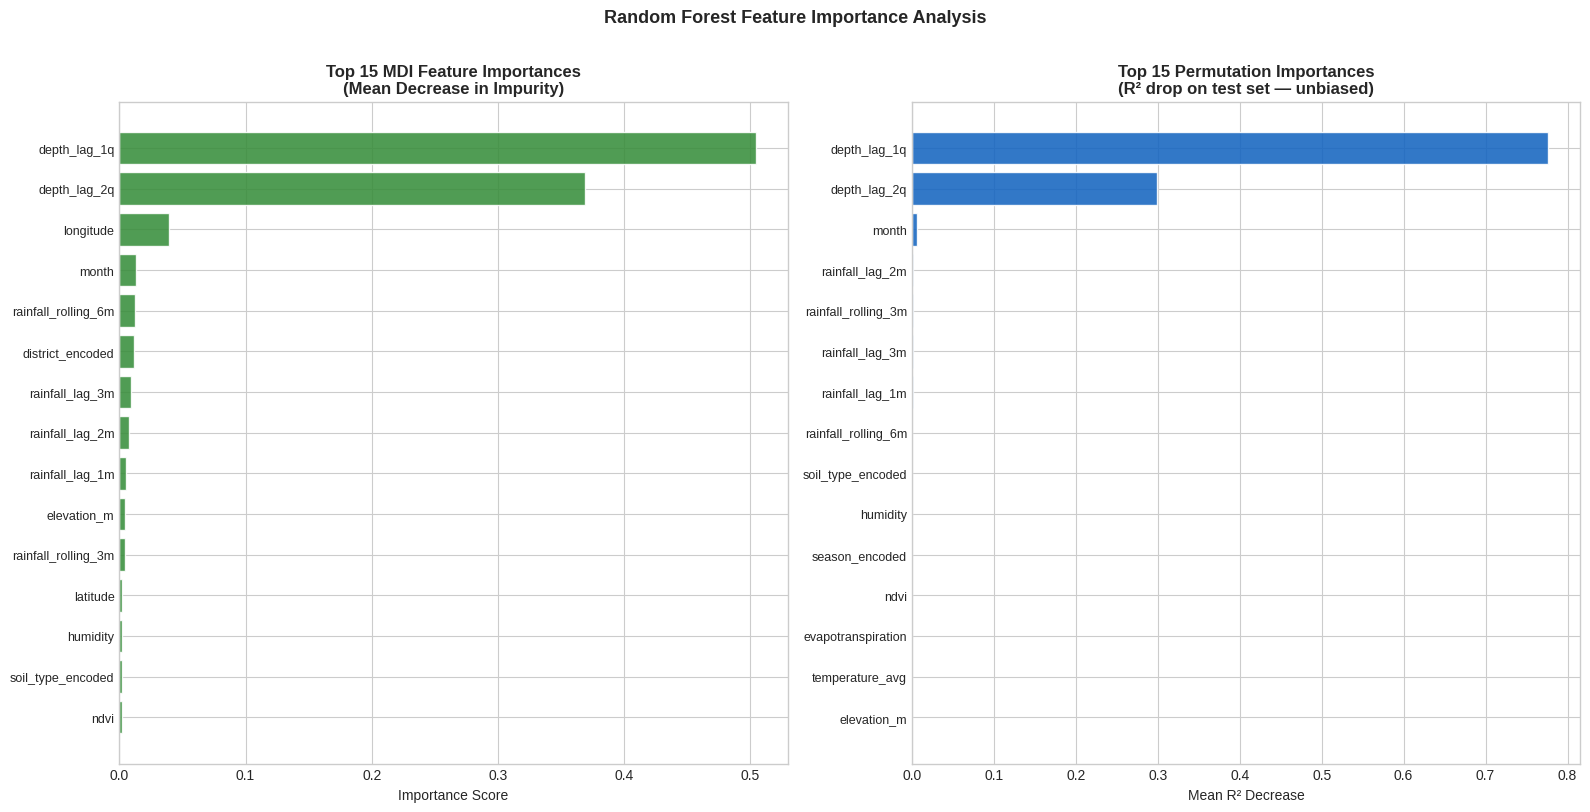

✅ Feature importance plot saved


In [14]:

# ============================================================
# STEP 10: FEATURE IMPORTANCE — MDI + PERMUTATION
# ============================================================

# ── 10a: MDI (Mean Decrease in Impurity) ──────────────────
mdi_importances = pd.Series(rf_final.feature_importances_, index=FEATURES
                            ).sort_values(ascending=False)

print("📊 Top 15 MDI Feature Importances:")
print(mdi_importances.head(15).to_string())

# ── 10b: Permutation Importance (on test set) ─────────────
print("\n🔄 Computing Permutation Importance on test set (n_repeats=10)...")
t0 = time.time()
perm_result = permutation_importance(
    rf_final, X_test, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="r2",
)
print(f"   Done in {time.time()-t0:.1f}s")

perm_importances = pd.Series(
    perm_result.importances_mean, index=FEATURES
).sort_values(ascending=False)

print("\n📊 Top 15 Permutation Importances (Mean R² decrease):")
print(perm_importances.head(15).to_string())

# ── Plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_n = min(15, len(FEATURES))

# MDI
mdi_top = mdi_importances.head(top_n)
axes[0].barh(range(top_n), mdi_top.values[::-1], color="#388E3C", edgecolor="white", alpha=0.88)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(mdi_top.index[::-1], fontsize=9)
axes[0].set_title(f"Top {top_n} MDI Feature Importances\n(Mean Decrease in Impurity)",
                  fontweight="bold")
axes[0].set_xlabel("Importance Score")

# Permutation
perm_top = perm_importances.head(top_n)
axes[1].barh(range(top_n), perm_top.values[::-1], color="#1565C0", edgecolor="white", alpha=0.88)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(perm_top.index[::-1], fontsize=9)
axes[1].set_title(f"Top {top_n} Permutation Importances\n(R² drop on test set — unbiased)",
                  fontweight="bold")
axes[1].set_xlabel("Mean R² Decrease")

plt.suptitle("Random Forest Feature Importance Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Feature importance plot saved")


---
## 🎯 Step 11 — Out-of-Bag (OOB) Score Deep Dive

> Random Forest trains each tree on ~63% of data (bootstrap sample). The remaining ~37% (**OOB samples**) act as a free internal validation set — no need for a separate hold-out.

📊 Computing OOB scores for n_estimators convergence...
   n_estimators=  50  OOB R²=0.9832
   n_estimators= 100  OOB R²=0.9836
   n_estimators= 150  OOB R²=0.9838
   n_estimators= 200  OOB R²=0.9839
   n_estimators= 300  OOB R²=0.9839
   n_estimators= 400  OOB R²=0.9839
   n_estimators= 500  OOB R²=0.9839

✅ Final model OOB R² (train+val, n=150 trees): 0.9841


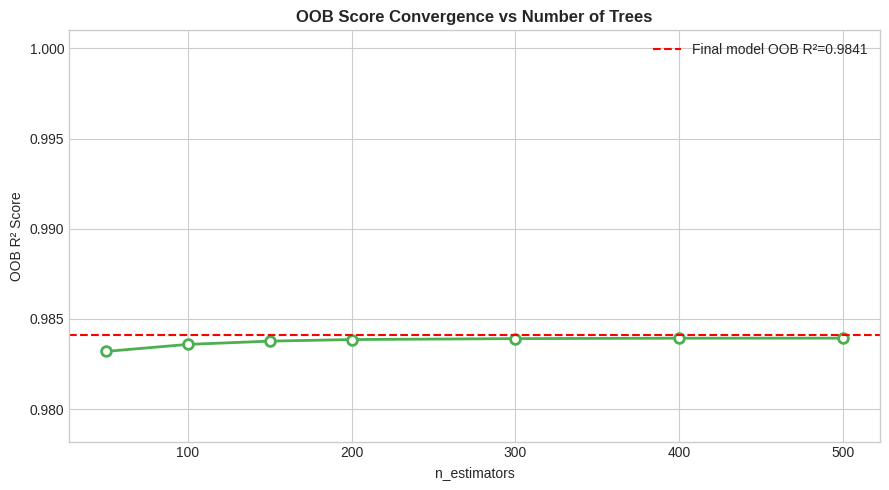

✅ OOB convergence plot saved


In [16]:

# ============================================================
# STEP 11: OOB SCORE — n_estimators convergence analysis
# ============================================================

estimator_range = [50, 100, 150, 200, 300, 400, 500]
oob_scores = []

print("📊 Computing OOB scores for n_estimators convergence...")
for n in estimator_range:
    rf_oob = RandomForestRegressor(
        n_estimators=n,
        max_depth=best_params.get("max_depth", None),
        min_samples_split=best_params.get("min_samples_split", 2),
        min_samples_leaf=best_params.get("min_samples_leaf", 1),
        max_features=best_params.get("max_features", "sqrt"),
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    rf_oob.fit(X_train, y_train)
    oob_scores.append(rf_oob.oob_score_)
    print(f"   n_estimators={n:4d}  OOB R²={rf_oob.oob_score_:.4f}")

print(f"\n✅ Final model OOB R² (train+val, "
      f"n={rf_final.n_estimators} trees): {rf_final.oob_score_:.4f}")

# ── Plot OOB convergence ───────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(estimator_range, oob_scores, "o-", color="#4CAF50", linewidth=2,
        markersize=7, markerfacecolor="white", markeredgewidth=2)
ax.axhline(rf_final.oob_score_, color="red", linestyle="--",
           label=f"Final model OOB R²={rf_final.oob_score_:.4f}")
ax.set_xlabel("n_estimators")
ax.set_ylabel("OOB R² Score")
ax.set_title("OOB Score Convergence vs Number of Trees", fontweight="bold")
ax.legend()
ax.set_ylim(min(oob_scores) - 0.005, 1.001)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_oob_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ OOB convergence plot saved")


---
## 📊 Step 12 — Cross-Validation & Learning Curve

📊 Running 5-fold TimeSeriesSplit CV (R²)...
   R²   per fold : [0.9315 0.9805 0.9628 0.9661 0.9762]
   R²   mean±std : 0.9634 ± 0.0172

   RMSE per fold : [0.2944 0.1607 0.216  0.2094 0.1653]  (log-space)
   RMSE mean±std : 0.2092 ± 0.0482


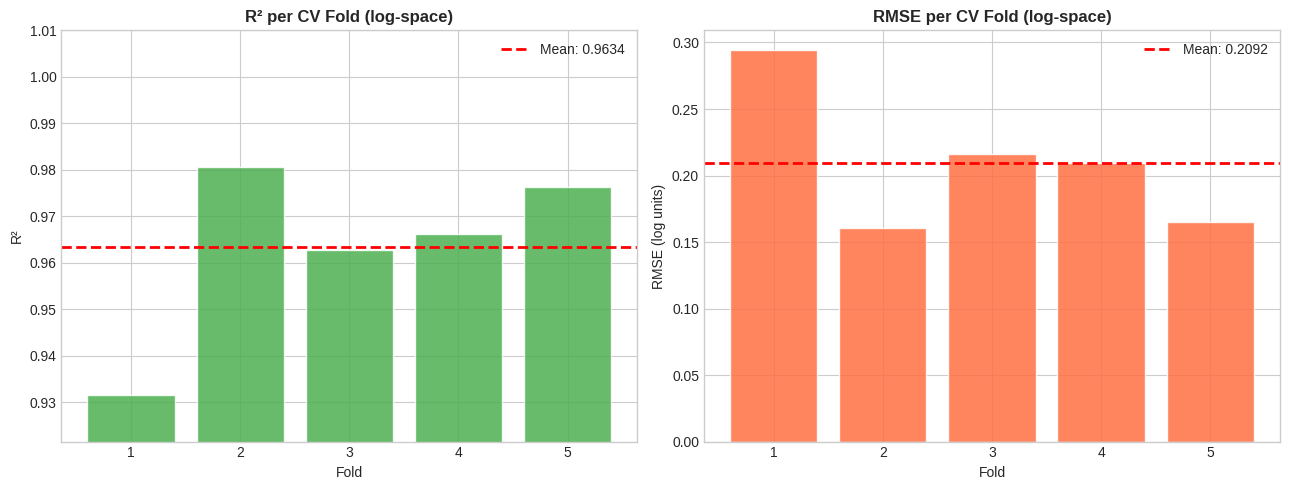

✅ Cross-validation plots saved


In [17]:
# ============================================================
# STEP 12a: TIME-SERIES CROSS-VALIDATION (5-fold)
# ============================================================
# ⚡ n_jobs=1 on cross_val_score → avoids Windows loky subprocess overhead
#    RF itself uses n_jobs=-1 (OpenMP threads) for speed

tscv_eval = TimeSeriesSplit(n_splits=5)

rf_cv = RandomForestRegressor(
    **{k: v for k, v in best_params.items()},
    oob_score=False,
    n_jobs=-1,          # ← RF threads, fast
    random_state=RANDOM_STATE,
)

print("📊 Running 5-fold TimeSeriesSplit CV (R²)...")
cv_scores_r2 = cross_val_score(rf_cv, X_train, y_train, cv=tscv_eval,
                                scoring="r2", n_jobs=1)   # ← sequential outer loop
print(f"   R²   per fold : {cv_scores_r2.round(4)}")
print(f"   R²   mean±std : {cv_scores_r2.mean():.4f} ± {cv_scores_r2.std():.4f}")

cv_scores_rmse = cross_val_score(rf_cv, X_train, y_train, cv=tscv_eval,
                                  scoring="neg_root_mean_squared_error", n_jobs=1)
print(f"\n   RMSE per fold : {(-cv_scores_rmse).round(4)}  (log-space)")
print(f"   RMSE mean±std : {(-cv_scores_rmse).mean():.4f} ± {(-cv_scores_rmse).std():.4f}")

# ── Plot CV scores ─────────────────────────────────────────
folds = np.arange(1, 6)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(folds, cv_scores_r2, color="#4CAF50", alpha=0.85, edgecolor="white")
axes[0].axhline(cv_scores_r2.mean(), color="red", linewidth=2, linestyle="--",
                label=f"Mean: {cv_scores_r2.mean():.4f}")
axes[0].set_title("R² per CV Fold (log-space)", fontweight="bold")
axes[0].set_xlabel("Fold"); axes[0].set_ylabel("R²"); axes[0].legend()
axes[0].set_ylim(max(0, cv_scores_r2.min() - 0.01), 1.01)

axes[1].bar(folds, -cv_scores_rmse, color="#FF7043", alpha=0.85, edgecolor="white")
axes[1].axhline(-cv_scores_rmse.mean(), color="red", linewidth=2, linestyle="--",
                label=f"Mean: {-cv_scores_rmse.mean():.4f}")
axes[1].set_title("RMSE per CV Fold (log-space)", fontweight="bold")
axes[1].set_xlabel("Fold"); axes[1].set_ylabel("RMSE (log units)"); axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_cross_validation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Cross-validation plots saved")


📈 Computing Learning Curve...


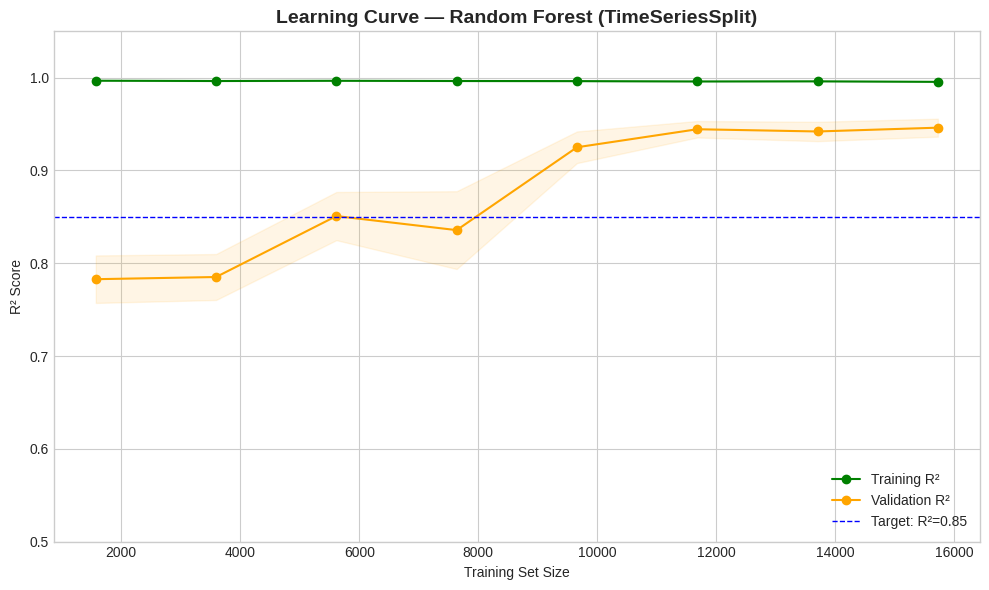

✅ Learning curve plot saved


In [18]:

# ============================================================
# STEP 12b: LEARNING CURVE
# ============================================================
# ⚡ n_jobs=1 on learning_curve → avoids Windows loky subprocess overhead

print("📈 Computing Learning Curve...")

tscv_lc = TimeSeriesSplit(n_splits=3)

train_sizes, train_scores, val_scores = learning_curve(
    rf_cv, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),   # 8 points instead of 10
    cv=tscv_lc, scoring="r2",
    n_jobs=1,                                 # ← sequential: no subprocess overhead
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.1, color="green")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.1, color="orange")
ax.plot(train_sizes, train_mean, "o-", color="green",  label="Training R²")
ax.plot(train_sizes, val_mean,   "o-", color="orange", label="Validation R²")
ax.axhline(0.85, color="blue", linewidth=1, linestyle="--", label="Target: R²=0.85")
ax.set_title("Learning Curve — Random Forest (TimeSeriesSplit)", fontsize=14, fontweight="bold")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("R² Score")
ax.legend(loc="lower right")
ax.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Learning curve plot saved")


---
## 🚨 Step 13 — Risk Classification from Predictions

Convert continuous depth predictions to 4-level risk alerts.

| Level | Depth Range | Meaning |
|---|---|---|
| 🟢 **SAFE** | < 30 m | Adequate groundwater |
| 🟡 **WARNING** | 30 – 100 m | Monitor closely |
| 🟠 **CRITICAL** | 100 – 200 m | Activate conservation |
| 🔴 **EXTREME** | > 200 m | Emergency intervention |

  RISK CLASSIFICATION RESULTS (Test Set)

📊 Risk Classification Accuracy: 96.5%

📊 Classification Report:
              precision    recall  f1-score   support

        SAFE       0.98      0.98      0.98      3118
     WARNING       0.97      0.98      0.97      3541
    CRITICAL       0.94      0.97      0.95      2687
     EXTREME       0.97      0.88      0.92      1136

    accuracy                           0.96     10482
   macro avg       0.96      0.95      0.96     10482
weighted avg       0.97      0.96      0.96     10482



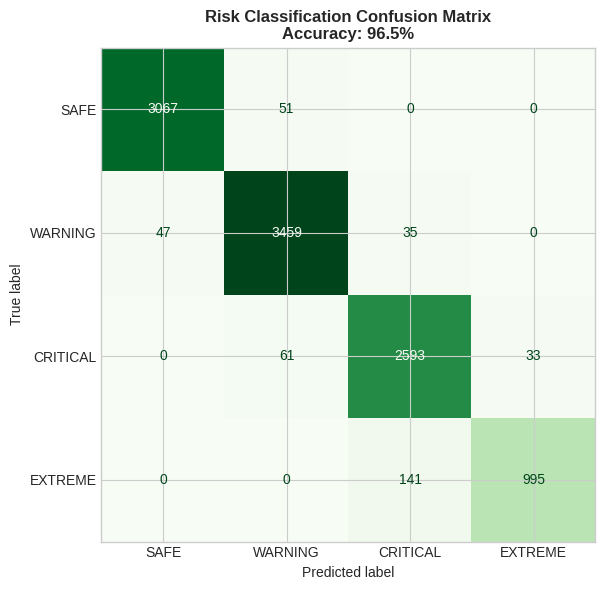

✅ Confusion matrix saved

📊 Predicted Risk Level Distribution (Test set):
   CRITICAL  : 2,769  (26.4%)
   EXTREME   : 1,028  (9.8%)
   SAFE      : 3,114  (29.7%)


In [19]:

# ============================================================
# STEP 13: RISK CLASSIFICATION
# ============================================================

from sklearn.metrics import classification_report, accuracy_score

def classify_risk(depth_m):
    """Map depth (metres) to 4-level risk category."""
    if   depth_m < 30:   return "SAFE"
    elif depth_m < 100:  return "WARNING"
    elif depth_m < 200:  return "CRITICAL"
    else:                return "EXTREME"

y_true_risk = np.array([classify_risk(d) for d in y_true_test])
y_pred_risk = np.array([classify_risk(d) for d in y_pred_test])

acc = accuracy_score(y_true_risk, y_pred_risk)
print("=" * 60)
print("  RISK CLASSIFICATION RESULTS (Test Set)")
print("=" * 60)
print(f"\n📊 Risk Classification Accuracy: {acc*100:.1f}%")
print("\n📊 Classification Report:")
print(classification_report(y_true_risk, y_pred_risk,
      labels=["SAFE", "WARNING", "CRITICAL", "EXTREME"]))

# ── Confusion matrix ───────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels_order = ["SAFE", "WARNING", "CRITICAL", "EXTREME"]
cm = confusion_matrix(y_true_risk, y_pred_risk, labels=labels_order)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, colorbar=False, cmap="Greens")
ax.set_title(f"Risk Classification Confusion Matrix\nAccuracy: {acc*100:.1f}%",
             fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/09_risk_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix saved")

# ── Distribution of predicted risk levels ─────────────────
unique, counts = np.unique(y_pred_risk, return_counts=True)
print("\n📊 Predicted Risk Level Distribution (Test set):")
for label, count in zip(unique, counts):
    print(f"   {label:<10}: {count:5,}  ({count/len(y_pred_risk)*100:.1f}%)")


---
## 💾 Step 14 — Save Model & Artifacts

In [20]:

# ============================================================
# STEP 14: SAVE MODEL & ARTIFACTS
# ============================================================

MODEL_PATH    = f"{MODEL_DIR}/random_forest_temporal.joblib"
METRICS_PATH  = f"{OUTPUT_DIR}/rf_metrics.json"
PARAMS_PATH   = f"{OUTPUT_DIR}/rf_best_params.json"
FEAT_IMP_PATH = f"{OUTPUT_DIR}/rf_feature_importances.csv"

# ── Save model ─────────────────────────────────────────────
joblib.dump(rf_final, MODEL_PATH, compress=3)
size_mb = os.path.getsize(MODEL_PATH) / (1024 ** 2)
print(f"💾 Model saved → {MODEL_PATH}  ({size_mb:.1f} MB)")

# ── Save metrics as JSON ───────────────────────────────────
metrics = {
    "model"         : "RandomForestRegressor",
    "target"        : "depth_mbgl",
    "transform"     : "log1p / expm1",
    "split"         : "75% train / 12.5% val / 12.5% test (row-index)",
    "features_used" : len(FEATURES),
    "train": {
        "R2"   : round(final_train["R2"],   4),
        "RMSE" : round(final_train["RMSE"], 4),
        "MAE"  : round(final_train["MAE"],  4),
        "MdAPE": round(final_train["MdAPE"],4),
    },
    "val": {
        "R2"   : round(final_val_only["R2"],   4),
        "RMSE" : round(final_val_only["RMSE"], 4),
        "MAE"  : round(final_val_only["MAE"],  4),
        "MdAPE": round(final_val_only["MdAPE"],4),
    },
    "test": {
        "R2"   : round(final_test["R2"],   4),
        "RMSE" : round(final_test["RMSE"], 4),
        "MAE"  : round(final_test["MAE"],  4),
        "MdAPE": round(final_test["MdAPE"],4),
        "risk_accuracy_pct": round(acc * 100, 1),
    },
    "oob_r2_trainval" : round(rf_final.oob_score_, 4),
    "cv_r2_mean"      : round(cv_scores_r2.mean(), 4),
    "cv_r2_std"       : round(cv_scores_r2.std(),  4),
}

with open(METRICS_PATH, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"📊 Metrics saved  → {METRICS_PATH}")

# ── Save best params ───────────────────────────────────────
params_to_save = {str(k): (None if v is None else v)
                  for k, v in best_params.items()}
with open(PARAMS_PATH, "w") as f:
    json.dump(params_to_save, f, indent=2)
print(f"⚙️  Params saved   → {PARAMS_PATH}")

# ── Save feature importances ───────────────────────────────
fi_df = pd.DataFrame({
    "feature"            : FEATURES,
    "mdi_importance"     : rf_final.feature_importances_,
    "perm_importance"    : perm_result.importances_mean,
    "perm_importance_std": perm_result.importances_std,
}).sort_values("mdi_importance", ascending=False)
fi_df.to_csv(FEAT_IMP_PATH, index=False)
print(f"📁 Feature importances → {FEAT_IMP_PATH}")

# ── Summary card ───────────────────────────────────────────
print("\n" + "=" * 62)
print("  ✅  RANDOM FOREST TEMPORAL ENGINE — COMPLETE")
print("=" * 62)
print(f"  Model       : RandomForestRegressor")
print(f"  n_estimators: {rf_final.n_estimators}")
print(f"  max_depth   : {rf_final.max_depth}")
print(f"  OOB R²      : {rf_final.oob_score_:.4f}")
print(f"  CV R²       : {cv_scores_r2.mean():.4f} ± {cv_scores_r2.std():.4f}")
print(f"  Test R²     : {final_test['R2']:.4f}")
print(f"  Test RMSE   : {final_test['RMSE']:.2f} m")
print(f"  Test MAE    : {final_test['MAE']:.2f} m")
print(f"  Test MdAPE  : {final_test['MdAPE']:.2f}%")
print(f"  Risk Acc.   : {acc*100:.1f}%")
print("=" * 62)


💾 Model saved → /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/saved_models/random_forest_temporal.joblib  (55.4 MB)
📊 Metrics saved  → /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/outputs/random_forest/rf_metrics.json
⚙️  Params saved   → /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/outputs/random_forest/rf_best_params.json
📁 Feature importances → /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/outputs/random_forest/rf_feature_importances.csv

  ✅  RANDOM FOREST TEMPORAL ENGINE — COMPLETE
  Model       : RandomForestRegressor
  n_estimators: 150
  max_depth   : 30
  OOB R²      : 0.9841
  CV R²       : 0.9634 ± 0.0172
  Test R²     : 0.9950
  Test RMSE   : 5.23 m
  Test MAE    : 3.47 m
  Test MdAPE  : 4.11%
  Risk Acc.   : 96.5%


---
## 🔮 Step 15 — Inference Demo & Model Loading

Quick sanity check: reload the saved model and run a sample prediction.

In [21]:

# ============================================================
# STEP 15: INFERENCE DEMO — reload & predict
# ============================================================

# Load model from disk
rf_loaded = joblib.load(MODEL_PATH)
print(f"✅ Model loaded from {MODEL_PATH}")
print(f"   n_estimators : {rf_loaded.n_estimators}")
print(f"   max_depth    : {rf_loaded.max_depth}")

# Take 5 random test samples
rng = np.random.default_rng(seed=7)
sample_idx = rng.choice(len(X_test), size=5, replace=False)
X_sample = X_test[sample_idx]
y_sample_true_raw = y_test_raw[sample_idx]

# Predict (log-space → invert to metres)
y_sample_pred_log = rf_loaded.predict(X_sample)
y_sample_pred_raw = np.expm1(y_sample_pred_log).clip(min=0)

print(f"\n{'Sample':<8} {'True (m)':>10} {'Pred (m)':>10} {'Err (m)':>10} {'Risk (True)':>14} {'Risk (Pred)':>14}")
print("-" * 72)
for i, (true, pred) in enumerate(zip(y_sample_true_raw, y_sample_pred_raw)):
    err = pred - true
    print(f"{i+1:<8} {true:>10.2f} {pred:>10.2f} {err:>+10.2f} "
          f"{classify_risk(true):>14} {classify_risk(pred):>14}")

print("\n🎉  Random Forest Temporal Engine notebook complete!")
print(f"    All outputs saved to  {OUTPUT_DIR}")
print(f"    Model saved to        {MODEL_PATH}")


✅ Model loaded from /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/saved_models/random_forest_temporal.joblib
   n_estimators : 150
   max_depth    : 30

Sample     True (m)   Pred (m)    Err (m)    Risk (True)    Risk (Pred)
------------------------------------------------------------------------
1             34.57      33.57      -1.00        WARNING        WARNING
2              7.59       6.67      -0.92           SAFE           SAFE
3             37.04      37.04      +0.01        WARNING        WARNING
4             39.68      41.22      +1.54        WARNING        WARNING
5            198.56     174.44     -24.12       CRITICAL       CRITICAL

🎉  Random Forest Temporal Engine notebook complete!
    All outputs saved to  /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/outputs/random_forest
    Model saved to        /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/saved_models/random_forest_temporal.joblib
